<a href="https://colab.research.google.com/github/XM2202-02/NHAN-DIEN/blob/main/PALM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,Dropout

In [2]:
datagen = ImageDataGenerator(rescale=1./255)
generator= datagen.flow_from_directory(
    '/content/drive/MyDrive/PALM_TRAIN',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)
test_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/PALM_VAL',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    seed=42
)
class_label=['Elon Musk','Miss TThuy','Misthy','Quan0go','The Weeknd','Tlinh']
X_batch,y_batch= next(generator)
X_batch_flat=X_batch.reshape(X_batch.shape[0],-1)
x_train, y_train = next(generator)
x_test, y_test = next(test_generator)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
print('Nhap vao:', X_batch_flat.shape)
print('Ket qua:', y_batch.shape)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

Found 88 images belonging to 3 classes.
Found 89 images belonging to 3 classes.
Nhap vao: (32, 3072)
Ket qua: (32, 3)
(32, 3072) (32, 3)
(32, 3072) (32, 3)


In [4]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(32*32*3,)),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test))
test_loss, test_acc = model.evaluate(x_test, y_test)
print('test_acc:%.2f'%(test_acc))
generator.class_indices

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4062 - loss: 1.3274 - val_accuracy: 0.0000e+00 - val_loss: 7.9811
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.3750 - loss: 3.1918 - val_accuracy: 0.0625 - val_loss: 3.0411
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3750 - loss: 1.6021 - val_accuracy: 0.9375 - val_loss: 0.2762
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3750 - loss: 1.9441 - val_accuracy: 0.9375 - val_loss: 0.4495
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.3750 - loss: 1.4160 - val_accuracy: 0.0000e+00 - val_loss: 1.5363
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4375 - loss: 0.9348 - val_accuracy: 0.0625 - val_loss: 2.4303
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7188 - loss: 0.8839 - val_accuracy: 0.0625 - val_loss: 2.7186
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5312 - loss: 0.9749 - val_accuracy: 0.0625 - 

{'Masha': 0, 'Thomas': 1, 'jessica': 2}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Dự đoán: Masha


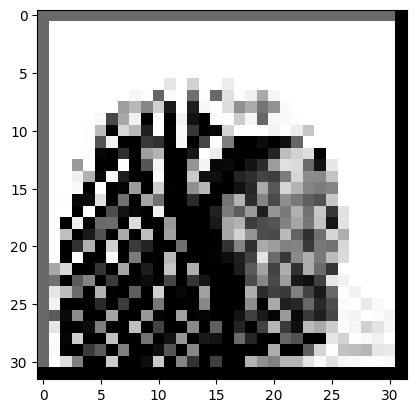

In [5]:
img=load_img('/content/drive/MyDrive/PALM_TRAIN/Masha/101__M_Left_index_finger_Obl.bmp', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img_flatten.astype('float32') / 255
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Dự đoán: jessica


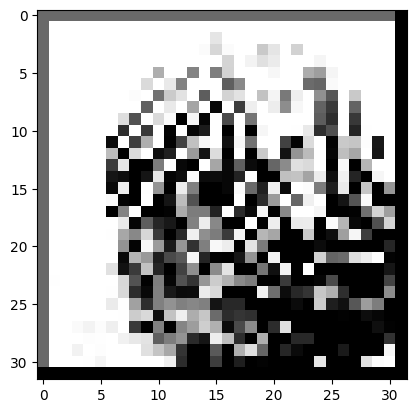

In [7]:
img=load_img('/content/drive/MyDrive/PALM_TRAIN/jessica/100__M_Left_little_finger_CR.jpg', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img_flatten.astype('float32') / 255
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])